# 1. Налаштування середовища та завантаження бібліотек

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Для токенізації та словника
from collections import Counter
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm

# Для візуалізації
import matplotlib.pyplot as plt
import seaborn as sns

# Завантажте необхідні ресурси NLTK, якщо вони ще не завантажені
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')

# 2. Завантаження та попередня обробка даних

## 2.1 Завантаження та присвоєння міток

In [26]:
df_fake = pd.read_csv('Fake.csv')
df_true = pd.read_csv('True.csv')

# Присвоєння міток (0 = Real, 1 = Fake)
df_fake['label'] = 1
df_true['label'] = 0

# Об'єднання датасетів
df = pd.concat([df_fake, df_true], ignore_index=True)

# Використовуємо 'Title' + 'Text' як вхідну послідовність
df['full_text'] = df['title'] + " " + df['text']
data = df[['full_text', 'label']]

print(f"Загальна кількість статей: {len(data)}")

Загальна кількість статей: 44898


## 2.2 Мінімальне очищення тексту та токенізація

In [27]:
def clean_text(text):
    text = text.lower() # Нижній регістр
    text = re.sub(r'[^a-z0-9\s]', '', text) # Видалення надлишкової пунктуації/символів
    return text

data['cleaned_text'] = data['full_text'].apply(clean_text)

# Проста токенізація на слова
data['tokens'] = data['cleaned_text'].apply(nltk.word_tokenize)

C:\Users\Андрій\AppData\Local\Temp\ipykernel_24132\3796513404.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['cleaned_text'] = data['full_text'].apply(clean_text)
Exception ignored in: <function tqdm.__del__ at 0x0000019E2B48C680>
Traceback (most recent call last):
  File "f:\Python\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "f:\Python\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x0000019E2B48C680>
Traceback (most recent call last):
  File "f:\Python\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.clo

## 2.3 Побудова словника

In [28]:
all_tokens = [token for sublist in data['tokens'] for token in sublist]
word_counts = Counter(all_tokens)

# Обмеження розміру словника
VOCAB_SIZE = 50000
vocabulary = {word: i + 2 for i, (word, count) in enumerate(word_counts.most_common(VOCAB_SIZE - 2))}
vocabulary['<unk>'] = 1 # Невідомий токен
vocabulary['<pad>'] = 0 # Токен заповнення

print(f"Розмір словника: {len(vocabulary)}")

Розмір словника: 50000


## 2.4 Перетворення токенів на індекси та заповнення/обрізання (Padding/Truncation)

In [29]:
MAX_LENGTH = 512 # Максимальна довжина L

def encode_and_pad(tokens, max_length):
    indices = [vocabulary.get(token, vocabulary['<unk>']) for token in tokens]
    if len(indices) < max_length:
        # Заповнення (Padding)
        indices += [vocabulary['<pad>']] * (max_length - len(indices))
    else:
        # Обрізання (Truncation)
        indices = indices[:max_length]
    return indices

data['encoded'] = data['tokens'].apply(lambda x: encode_and_pad(x, MAX_LENGTH))

C:\Users\Андрій\AppData\Local\Temp\ipykernel_24132\2234747769.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['encoded'] = data['tokens'].apply(lambda x: encode_and_pad(x, MAX_LENGTH))


## 2.5 Розбиття на train/validation/test

In [30]:
X = np.array(data['encoded'].tolist())
y = data['label'].values

# 80% train, 20% temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Розмір train: {len(X_train)}, validation: {len(X_val)}, test: {len(X_test)}")

Розмір train: 35918, validation: 4490, test: 4490


## 2.6 Створення PyTorch DataLoader

In [31]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Гіперпараметри для DataLoader
BATCH_SIZE = 64

train_dataset = NewsDataset(X_train, y_train)
val_dataset = NewsDataset(X_val, y_val)
test_dataset = NewsDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Архітектура моделей PyTorch

In [32]:
# Використовуємо GPU, якщо доступно
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Використовується пристрій: {device}")

Використовується пристрій: cuda


## 3.1 Simple RNN Classifier

In [33]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super().__init__()
        
        self.embedding = nn.Embedding(
            vocab_size, emb_dim, padding_idx=vocabulary['<pad>']
        )

        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=(dropout if num_layers > 1 else 0.0)
        )

        self.fc = nn.Linear(hidden_dim, 1) 

    def forward(self, x):
        emb = self.embedding(x) # (B, L, emb_dim) [c
        
        # out: (B, L, H), h_n: (layers, B, H)
        # h_n - містить прихований стан останнього часового кроку для кожного шару
        out, h_n = self.rnn(emb)
        
        # Використовуємо прихований стан останнього шару h_n[-1]
        last_hidden = h_n[-1] # (B, H)
        
        logits = self.fc(last_hidden).squeeze(1) # (B)
        
        # Вихідна ймовірність: $\hat{p}=\sigma(o)$
        return torch.sigmoid(logits), logits

## 3.2 LSTM Classifier

In [34]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, bidirectional=False, dropout=0.2):
        super().__init__()

        self.bidirectional = bidirectional
        
        self.embedding = nn.Embedding(
            vocab_size, emb_dim, padding_idx=vocabulary['<pad>']
        ) 

        self.lstm = nn.LSTM(
            input_size=emb_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            bidirectional=bidirectional,
            dropout=(dropout if num_layers > 1 else 0.0) 
        )
        
        # Якщо двонаправлена, прихований вихід має розмір hidden_dim * 2
        factor = 2 if bidirectional else 1 
        self.fc = nn.Linear(hidden_dim * factor, 1) 

    def forward(self, x):
        emb = self.embedding(x) # (B, L, emb_dim) 
        
        # out: (B, L, H*factor), h_n: (layers*factor, B, H), c_n: (layers*factor, B, H)
        out, (h_n, c_n) = self.lstm(emb) 
        
        # Прихований стан останнього шару. h_n має форму (num_layers * num_directions, batch, hidden_size)
        
        if self.bidirectional:
             # Об'єднуємо останній прямий (h_n[-2]) і останній зворотний (h_n[-1]) вихід
             last_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
             # Використовуємо прихований стан останнього шару
             last_hidden = h_n[-1] # (B, H) 
        
        logits = self.fc(last_hidden).squeeze(1) # (B) 
        
        return torch.sigmoid(logits), logits

# 4. Навчання та оцінка

In [35]:
# Встановлення фіксованого random seed для відтворюваності
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Гіперпараметри для порівняння ---
# Це *приклад* конфігурації. У реальному завданні слід виконати пошук за сіткою
HYPERPARAMS = {
    'emb_dim': 100, 
    'hidden_dim': 128, 
    'num_layers': 1, 
    'dropout': 0.2, 
    'LR': 1e-3, 
    'num_epochs': 5,
    'bidirectional': False, # (Тільки для LSTM)
    'model_type': None # Заповнюється в циклі
}

# Створення словника для збору результатів
results = {}

def evaluate_model(model, data_loader, device):
    """Обчислення метрик на даних"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            prob, _ = model(x_batch)
            all_probs.extend(prob.cpu().numpy())
            all_preds.extend((prob > 0.5).int().cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
    # Обчислення метрик
    metrics = {
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Precision': precision_score(all_labels, all_preds),
        'Recall': recall_score(all_labels, all_preds), 
        'F1-score': f1_score(all_labels, all_preds), 
        'ROC AUC': roc_auc_score(all_labels, all_probs),
        'Confusion_Matrix': confusion_matrix(all_labels, all_preds),
        'ROC_Curve_Data': (roc_curve(all_labels, all_probs), roc_auc_score(all_labels, all_probs))
    }
    return metrics

def train_model(model_type, hyperparams):
    
    print(f"--- Навчання {model_type} ---")
    
    # Ініціалізація моделі
    if model_type == 'RNN':
        model = SimpleRNNClassifier(
            vocab_size=len(vocabulary),
            emb_dim=hyperparams['emb_dim'],
            hidden_dim=hyperparams['hidden_dim'],
            num_layers=hyperparams['num_layers'],
            dropout=hyperparams['dropout']
        ).to(device)
    elif model_type == 'LSTM':
        model = LSTMClassifier(
            vocab_size=len(vocabulary),
            emb_dim=hyperparams['emb_dim'],
            hidden_dim=hyperparams['hidden_dim'],
            num_layers=hyperparams['num_layers'],
            bidirectional=hyperparams['bidirectional'],
            dropout=hyperparams['dropout']
        ).to(device)
    else:
        raise ValueError("Невідомий тип моделі")

    # Функція втрат та оптимізатор
    criterion = nn.BCEWithLogitsLoss() # (Оскільки модель повертає logits)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparams['LR']) 

    # Списки для кривих втрат/точності 
    train_losses = []
    val_losses = []
    train_f1s = []
    val_f1s = []
    
    best_val_f1 = -1

    for epoch in tqdm(range(hyperparams['num_epochs']), desc=f"{model_type} Epochs"):
        
        # --- Тренування ---
        model.train()
        total_loss = 0
        all_train_preds = []
        all_train_labels = []

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            
            prob, logits = model(x_batch)
            loss = criterion(logits, y_batch)
            
            loss.backward()
            
            # Обмеження градієнтів (Gradient Clipping)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            
            optimizer.step()
            
            total_loss += loss.item() * len(y_batch)
            all_train_preds.extend((prob > 0.5).int().cpu().numpy())
            all_train_labels.extend(y_batch.cpu().numpy())

        avg_train_loss = total_loss / len(train_dataset)
        train_f1 = f1_score(all_train_labels, all_train_preds)

        # --- Валідація ---
        val_metrics = evaluate_model(model, val_loader, device)
        
        # Обчислення втрат на валідації по батчах, щоб уникнути OOM
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                _, logits = model(x_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * len(y_batch)
        
        avg_val_loss = val_loss / len(val_dataset)
        val_f1 = val_metrics['F1-score']

        # Збереження результатів для кривих
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        print(f"Епоха {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1: {val_f1:.4f}")

        # Збереження найкращої моделі на основі F1 на валідації 
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f'{model_type}_best_model.pt')
    
    # Завантаження найкращої моделі
    model.load_state_dict(torch.load(f'{model_type}_best_model.pt'))
    
    # Оцінка на тестовому наборі
    test_metrics = evaluate_model(model, test_loader, device)

    # Збереження результатів
    results[model_type] = {
        'Test_Metrics': test_metrics,
        'Train_Loss_Curve': train_losses,
        'Val_Loss_Curve': val_losses,
        'Train_F1_Curve': train_f1s,
        'Val_F1_Curve': val_f1s,
        'Model_Size': sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

# --- Виконання тренування ---
HYPERPARAMS['model_type'] = 'RNN'
train_model('RNN', HYPERPARAMS)

# Зміна гіперпараметрів для LSTM
HYPERPARAMS['model_type'] = 'LSTM'
HYPERPARAMS['bidirectional'] = True # Спробуємо двонаправлену LSTM
train_model('LSTM', HYPERPARAMS)

--- Навчання RNN ---


RNN Epochs:  20%|██        | 1/5 [00:06<00:24,  6.23s/it]

Епоха 1: Train Loss: 0.6871, Val Loss: 0.6832, Val F1: 0.5956


RNN Epochs:  40%|████      | 2/5 [00:12<00:18,  6.09s/it]

Епоха 2: Train Loss: 0.6748, Val Loss: 0.6334, Val F1: 0.6991


...

LSTM Epochs:  80%|████████  | 4/5 [02:05<00:31, 31.45s/it]

Епоха 4: Train Loss: 0.0040, Val Loss: 0.0043, Val F1: 0.9994


LSTM Epochs: 100%|██████████| 5/5 [02:37<00:00, 31.43s/it]

Епоха 5: Train Loss: 0.0031, Val Loss: 0.0039, Val F1: 0.9996



C:\Users\Андрій\AppData\Local\Temp\ipykernel_24132\1441099230.py:148: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'{model_type}_best_mod

# 5. Результати та візуалізації

## 5.1 Таблиця метрик на тестовому наборі

In [36]:
def display_metrics_table(results):
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC']
    data = {}
    
    for model_name, res in results.items():
        data[model_name] = [res['Test_Metrics'][m] for m in metric_names]
        
    df_metrics = pd.DataFrame(data, index=metric_names).T
    df_metrics['Model Size (Params)'] = [res['Model_Size'] for res in results.values()] # 
    
    print("\n--- Порівняння моделей на тестовому наборі ---")
    print(df_metrics.to_markdown(floatfmt=".4f"))
    return df_metrics

df_results = display_metrics_table(results)


--- Порівняння моделей на тестовому наборі ---
|      |   Accuracy |   Precision |   Recall |   F1-score |   ROC AUC |   Model Size (Params) |
|:-----|-----------:|------------:|---------:|-----------:|----------:|----------------------:|
| RNN  |     0.7321 |      0.7406 |   0.7504 |     0.7455 |    0.7566 |          5029569.0000 |
| LSTM |     0.9978 |      0.9966 |   0.9991 |     0.9979 |    0.9991 |          5235777.0000 |


## 5.2 Криві втрат та F1

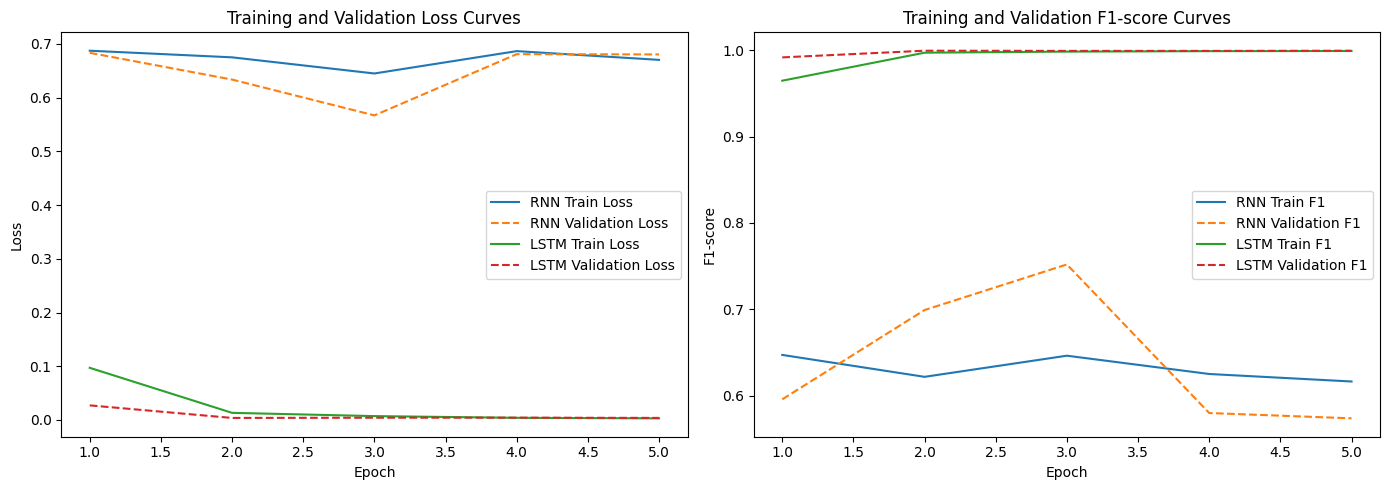

In [37]:
def plot_curves(results):
    epochs = range(1, len(next(iter(results.values()))['Train_Loss_Curve']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Криві втрат
    plt.subplot(1, 2, 1)
    for model_name, res in results.items():
        plt.plot(epochs, res['Train_Loss_Curve'], label=f'{model_name} Train Loss')
        plt.plot(epochs, res['Val_Loss_Curve'], label=f'{model_name} Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Криві F1-score
    plt.subplot(1, 2, 2)
    for model_name, res in results.items():
        plt.plot(epochs, res['Train_F1_Curve'], label=f'{model_name} Train F1')
        plt.plot(epochs, res['Val_F1_Curve'], label=f'{model_name} Validation F1', linestyle='--')
    plt.title('Training and Validation F1-score Curves')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_curves(results)

## 5.3 Матриця плутанини (Confusion Matrix)

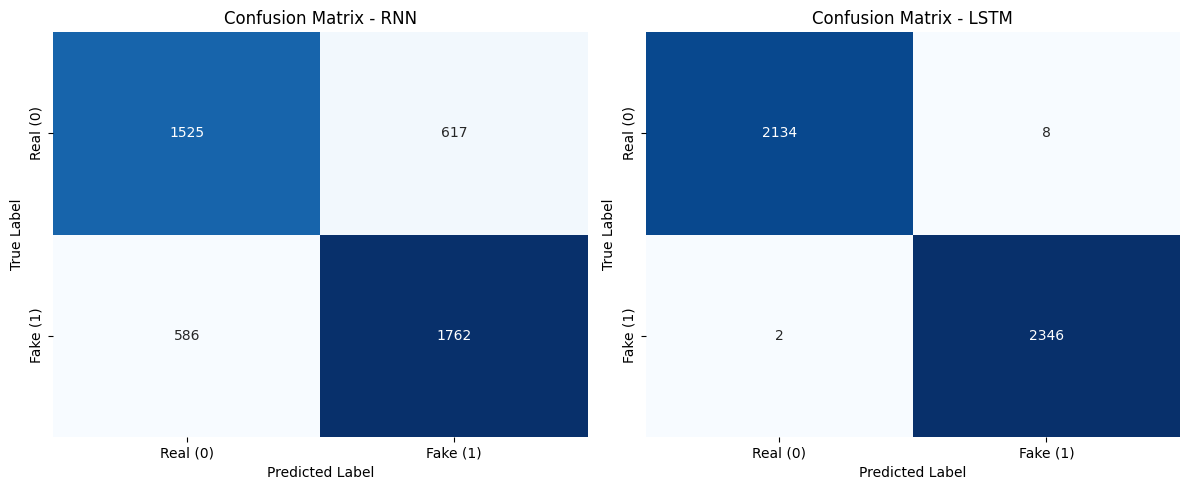

In [38]:
def plot_confusion_matrix(results):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for i, (model_name, res) in enumerate(results.items()):
        cm = res['Test_Metrics']['Confusion_Matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                    xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'],
                    ax=axes[i])
        axes[i].set_title(f'Confusion Matrix - {model_name}')
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')
        
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results)

## 5.4 ROC-крива

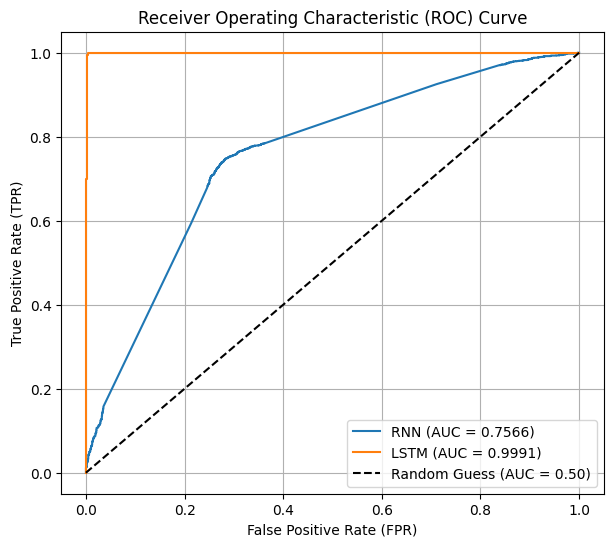

In [39]:
def plot_roc_curve(results):
    plt.figure(figsize=(7, 6))
    
    for model_name, res in results.items():
        fpr, tpr, _ = res['Test_Metrics']['ROC_Curve_Data'][0]
        roc_auc = res['Test_Metrics']['ROC_Curve_Data'][1]
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')
        
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_roc_curve(results)